In [66]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [67]:
current = Path.cwd()
current

PosixPath('/Users/khuenguyen/Desktop/team-nuclear-family/notebooks')

In [68]:
military_data = Path(current/"../raw_data/military/military_boundary.geojson")
military_data

PosixPath('/Users/khuenguyen/Desktop/team-nuclear-family/notebooks/../raw_data/military/military_boundary.geojson')

# 1. Load dataset

In [69]:
df = gpd.read_file(military_data)
print(df.shape)
df.head()

(743, 19)


,OBJECTID,countryName,featureDescription,featureName,installationId,isCui,isFirrmaSite,isJointBase,mediaId,metadataId,mirtaLocationsIdpk,sdsId,siteName,siteOperationalStatus,siteReportingComponent,stateNameCode,SHAPE__Area,SHAPE__Length,geometry
0,1,United States of America,na,NAVMEDCEN Portsmouth VA,N57095,No,No,No,na,na,,7d7e44c7-47ad-4fb2-84e1-dd138acdfb6c,NAVMEDCEN Portsmouth VA,Active,US Navy,VA,7.365200e+05,4684.246317,"POLYGON ((-76.30961 36.84645, -76.30961 36.846..."
1,2,United States of America,na,NAVSUPPACT Hampton Roads VA,N57095,No,No,No,na,na,,8b011bb7-9e1d-4915-9465-09cad2612ab4,NAVSUPPACT Hampton Roads VA,Active,US Navy,VA,5.024407e+06,11348.633365,"POLYGON ((-76.3065 36.92811, -76.30628 36.9276..."
2,3,United States of America,na,NNSY South Gate,N32443,No,No,No,na,na,,01610704-e8c4-4b42-bc0e-9a172afa4357,NNSY South Gate,Active,US Navy,VA,5.927841e+05,3126.312475,"POLYGON ((-76.29926 36.80635, -76.29925 36.806..."
3,4,United States of America,na,Naval Support Activity Wash,N68469,No,No,No,na,na,,c7359a10-744f-4dcc-930e-ad8894bdcc75,Naval Support Activity Wash,Active,US Navy,DC,5.120055e+05,3076.107519,"POLYGON ((-76.99169 38.87636, -76.99784 38.876..."
4,5,United States of America,na,Arlington Service Ctr,N68469,No,No,No,na,na,,a6845150-ab6a-4f3d-9483-1c4b5432b3bc,Arlington Service Ctr,Active,US Navy,VA,1.296422e+05,1713.357685,"POLYGON ((-77.07863 38.86896, -77.07867 38.869..."


In [70]:
df.isnull().sum()

OBJECTID                   0
countryName                0
featureDescription         0
featureName                0
installationId             4
isCui                      0
isFirrmaSite               0
isJointBase                0
mediaId                    0
metadataId                 0
mirtaLocationsIdpk         0
sdsId                     77
siteName                   5
siteOperationalStatus      1
siteReportingComponent     0
stateNameCode              0
SHAPE__Area                0
SHAPE__Length              0
geometry                   0
dtype: int64

In [71]:
df.dtypes

OBJECTID                     int32
countryName                 object
featureDescription          object
featureName                 object
installationId              object
isCui                       object
isFirrmaSite                object
isJointBase                 object
mediaId                     object
metadataId                  object
mirtaLocationsIdpk          object
sdsId                       object
siteName                    object
siteOperationalStatus       object
siteReportingComponent      object
stateNameCode               object
SHAPE__Area                float64
SHAPE__Length              float64
geometry                  geometry
dtype: object

# 2. Check coordinate reference system

In [72]:
df.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

EPSG:4326 CRS is the coordinate system that refers to geographic locations as latitude and longitude. To calculate area with accuracy, we set the CRS of the dataset to EPSG:5070, one that represents locations in meters. 

In [73]:
df = df.to_crs(epsg = 5070)
df.crs

<Projected CRS: EPSG:5070>
Name: NAD83 / Conus Albers
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - CONUS onshore - Alabama; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming.
- bounds: (-124.79, 24.41, -66.91, 49.38)
Coordinate Operation:
- name: Conus Albers
- method: Albers Equal Area
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

# 3. Key columns

In [74]:
df.columns

Index(['OBJECTID', 'countryName', 'featureDescription', 'featureName',
       'installationId', 'isCui', 'isFirrmaSite', 'isJointBase', 'mediaId',
       'metadataId', 'mirtaLocationsIdpk', 'sdsId', 'siteName',
       'siteOperationalStatus', 'siteReportingComponent', 'stateNameCode',
       'SHAPE__Area', 'SHAPE__Length', 'geometry'],
      dtype='object')

Drop unused columns

In [75]:
df = df.drop(columns = ["countryName", "featureDescription", "installationId", "isCui", "isFirrmaSite",
                        "isJointBase", "mediaId", "metadataId", "mirtaLocationsIdpk", "sdsId",
                        "siteReportingComponent", "SHAPE__Area", "SHAPE__Length"])
df.columns = ["object_id", "feature_name", "site_name", "site_operational_status", "state_name", "geometry"]
df.head()

,object_id,feature_name,site_name,site_operational_status,state_name,geometry
0,1,NAVMEDCEN Portsmouth VA,NAVMEDCEN Portsmouth VA,Active,VA,"POLYGON ((1727061.31 1713113.23, 1727067.75 17..."
1,2,NAVSUPPACT Hampton Roads VA,NAVSUPPACT Hampton Roads VA,Active,VA,"POLYGON ((1725447.98 1722124.405, 1725476.933 ..."
2,3,NNSY South Gate,NNSY South Gate,Active,VA,"POLYGON ((1728880.705 1708905.137, 1728887.096..."
3,4,Naval Support Activity Wash,Naval Support Activity Wash,Active,DC,"POLYGON ((1622849.188 1923894.174, 1622331.317..."
4,5,Arlington Service Ctr,Arlington Service Ctr,Active,VA,"POLYGON ((1615689.192 1921600.773, 1615685.054..."


### `site_operational_status`
Explore which military bases are active or inactive. Only keep active military bases for nuclear siting blocking.

In [76]:
df["site_operational_status"].value_counts()

site_operational_status
Active                712
Closed                 13
Caretaker              10
excs                    4
Semi-Active             2
Environmental Hold      1
Name: count, dtype: int64

- **Active and Semi-Active**: military bases are still in use
- **Closed**: military bases are permanently closed
- **Caretaker**: military bases are on maintenance with no official operations
- **excs**: perhaps military bases are declared excess
- **Environmental hold**: stopped due to environmetal hazards reason

In [77]:
df = df[(df["site_operational_status"] == "Active") | (df["site_operational_status"] == "Semi-Active")]
print(df["site_operational_status"].value_counts())
print(f"Current number of observations: {df.shape[0]}")

site_operational_status
Active         712
Semi-Active      2
Name: count, dtype: int64
Current number of observations: 714


### `feature_name` and `site_name`

Check for unique and null values

In [78]:
print(f"Number of unique features: {df["feature_name"].nunique()}")
print(f"Number of unique sites: {df["site_name"].nunique()}")

Number of unique features: 714
Number of unique sites: 710


In [79]:
print(f"Features: {df["feature_name"].isnull().sum()} null values")
print(f"Sites: {df["site_name"].isnull().sum()} null values")

Features: 0 null values
Sites: 4 null values


### `state_name`
Check which states have the most military bases

In [80]:
df_state_counts = pd.DataFrame(df["state_name"].value_counts()).reset_index()
print(f"Number of states: {df["state_name"].nunique()}")
df_state_counts.head()

Number of states: 53


,state_name,count
0,CA,70
1,VA,41
2,FL,39
3,AL,31
4,TX,31


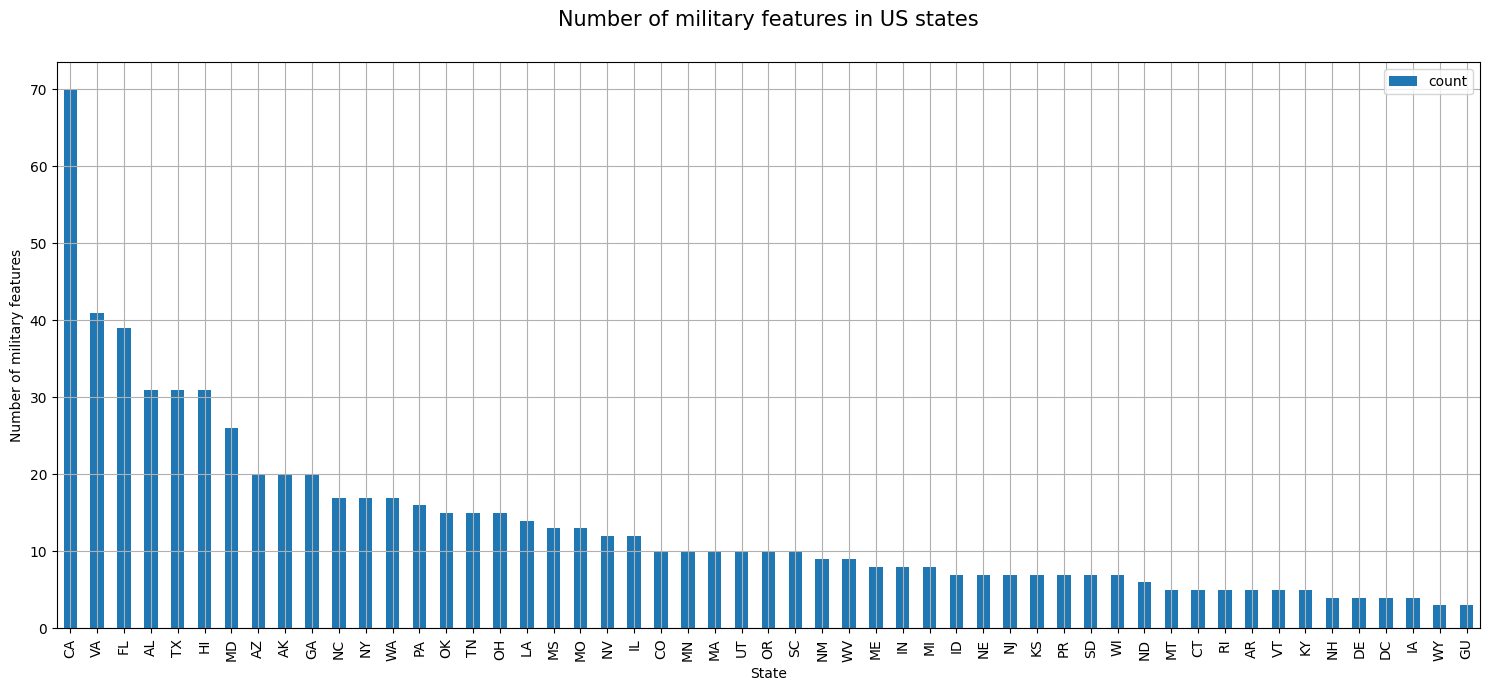

In [81]:
df_state_counts.plot.bar(
    figsize = (15,7), 
    x = "state_name",
    y = "count"
)
plt.xlabel("State")
plt.grid()
plt.ylabel("Number of military features")
plt.title("Number of military features in US states", fontsize = 15, y = 1.05)
plt.tight_layout()
plt.savefig("../results/military_by_states.png", bbox_inches = "tight")

##### Takeaways

**California**, **Virginia**, **Florida**, **Alabama**, and **Texas** are top 5 states in the US with the most military bases. Specifically: 

- California: 70 military bases
- Virginia: 41 military bases
- Florida: 39 military bases
- Alabama and Texas: 31 military bases each

Counties that intersect these installations will be flagged and excluded from candidate sites, which means these states are expected to have a higher proportion of restricted counties compared to others. 

### `area`

In [82]:
df["area"] = df.area
df.head()

,object_id,feature_name,site_name,site_operational_status,state_name,geometry,area
0,1,NAVMEDCEN Portsmouth VA,NAVMEDCEN Portsmouth VA,Active,VA,"POLYGON ((1727061.31 1713113.23, 1727067.75 17...",4.707725e+05
1,2,NAVSUPPACT Hampton Roads VA,NAVSUPPACT Hampton Roads VA,Active,VA,"POLYGON ((1725447.98 1722124.405, 1725476.933 ...",3.204949e+06
2,3,NNSY South Gate,NNSY South Gate,Active,VA,"POLYGON ((1728880.705 1708905.137, 1728887.096...",3.793155e+05
3,4,Naval Support Activity Wash,Naval Support Activity Wash,Active,DC,"POLYGON ((1622849.188 1923894.174, 1622331.317...",3.098846e+05
4,5,Arlington Service Ctr,Arlington Service Ctr,Active,VA,"POLYGON ((1615689.192 1921600.773, 1615685.054...",7.847789e+04


In [83]:
df["area"].head()

0    4.707725e+05
1    3.204949e+06
2    3.793155e+05
3    3.098846e+05
4    7.847789e+04
Name: area, dtype: float64

In [84]:
print(f"Numerical summary of area: \n\n{df["area"].describe()}")

Numerical summary of area: 

count    7.140000e+02
mean     1.272450e+08
std      6.934992e+08
min      3.137470e+00
25%      4.905658e+05
50%      2.679359e+06
75%      2.203549e+07
max      1.168994e+10
Name: area, dtype: float64


#### Area histogram distribution without scale

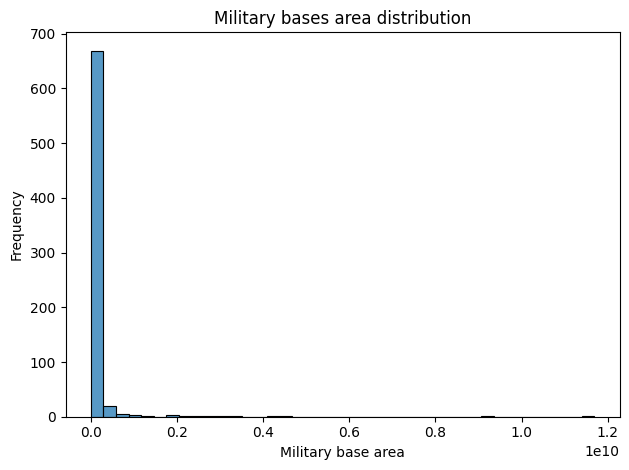

In [85]:
sns.histplot(
    data = df,
    x = "area",
    bins = 40
)
plt.xlabel("Military base area")
plt.ylabel("Frequency")
plt.title("Military bases area distribution")
plt.tight_layout()
plt.savefig("../results/military_area_no_scale.png", bbox_inches = "tight")

In [86]:
2.679359e+06

2679359.0

##### Takeaway

The distribution of the area of military bases is heavily right skewed, with the median area around 2,679,359 squared meters. To observe the detailed, underlying distribution of the area, we applied the log10 scale to the area to address this level of skewness.

#### Area histogram distribution with log10 scale
Based on the numerical summary and the histogram, the distribution of the area of military bases in the US is heavily right-skewed; therefore, we applied a log10 scale on the `shape_area` variable to observe the underlying detailed distribution

In [87]:
df["area_log10"] = np.log10(df["area"])
df.head()

,object_id,feature_name,site_name,site_operational_status,state_name,geometry,area,area_log10
0,1,NAVMEDCEN Portsmouth VA,NAVMEDCEN Portsmouth VA,Active,VA,"POLYGON ((1727061.31 1713113.23, 1727067.75 17...",4.707725e+05,5.672811
1,2,NAVSUPPACT Hampton Roads VA,NAVSUPPACT Hampton Roads VA,Active,VA,"POLYGON ((1725447.98 1722124.405, 1725476.933 ...",3.204949e+06,6.505821
2,3,NNSY South Gate,NNSY South Gate,Active,VA,"POLYGON ((1728880.705 1708905.137, 1728887.096...",3.793155e+05,5.579001
3,4,Naval Support Activity Wash,Naval Support Activity Wash,Active,DC,"POLYGON ((1622849.188 1923894.174, 1622331.317...",3.098846e+05,5.491200
4,5,Arlington Service Ctr,Arlington Service Ctr,Active,VA,"POLYGON ((1615689.192 1921600.773, 1615685.054...",7.847789e+04,4.894747


In [88]:
print(f"Numerical summary of area_log10: \n\n{df["area_log10"].describe()}")

Numerical summary of area_log10: 

count    714.000000
mean       6.566145
std        1.186317
min        0.496580
25%        5.690697
50%        6.428018
75%        7.343122
max       10.067812
Name: area_log10, dtype: float64


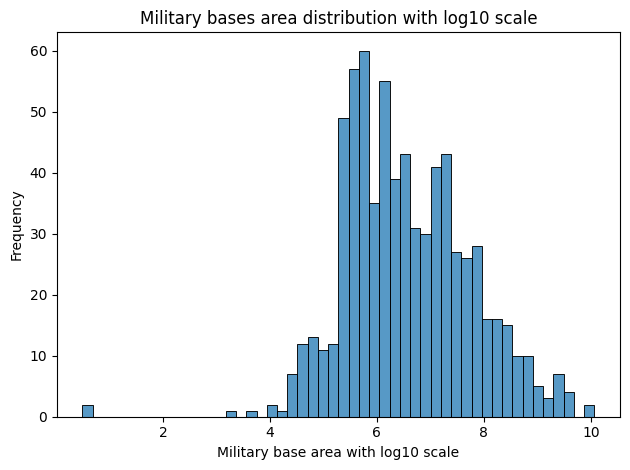

In [89]:
sns.histplot(
    data = df,
    x = "area_log10",
    bins = 50
)

plt.xlabel("Military base area with log10 scale")
plt.ylabel("Frequency")
plt.title("Military bases area distribution with log10 scale")
plt.tight_layout()
plt.savefig("../results/military_area_log10.png", bbox_inches = "tight")

# 4. Spatial join with counties

In [90]:
df_county = gpd.read_file("../raw_data/county_boundaries_2025/tl_2025_us_county.shp")
print(f"Before conversion: {df_county.crs}")
if df_county.crs != df.crs: 
    df_county = df_county.to_crs(df.crs)
print(f"After conversion: {df_county.crs}")
df_county.head()

Before conversion: EPSG:4269
After conversion: EPSG:5070


,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,40,075,01101825,40075,0500000US40075,Kiowa,Kiowa County,06,H1,G4020,None,None,None,A,2629039892,40296743,+34.9214893,-098.9816168,"POLYGON ((-267035.259 1343980.561, -266490.502..."
1,46,079,01265776,46079,0500000US46079,Lake,Lake County,06,H1,G4020,None,None,None,A,1457916151,31746795,+44.0284497,-097.1232229,"POLYGON ((-71100.31 2327435.998, -71100.293 23..."
2,37,033,01008542,37033,0500000US37033,Caswell,Caswell County,06,H1,G4020,None,None,None,A,1102042927,8293623,+36.3943252,-079.3396193,"POLYGON ((1489331.21 1620697.325, 1489336.836 ..."
3,48,377,01383974,48377,0500000US48377,Presidio,Presidio County,06,H1,G4020,None,None,None,A,9985057447,1773188,+30.0058912,-104.2616192,"POLYGON ((-857749.848 879396.771, -857744.209 ..."
4,39,057,01074041,39057,0500000US39057,Greene,Greene County,06,H1,G4020,212,19430,None,A,1071302625,6798109,+39.6874785,-083.8948943,"POLYGON ((1008169.795 1915287.022, 1008161.905..."


In [91]:
df_county = df_county.drop(columns = ["COUNTYNS", "GEOIDFQ", "NAME", "LSAD", "CLASSFP", "MTFCC", "CSAFP", "CBSAFP", 
                                      "METDIVFP", "FUNCSTAT", "ALAND", "AWATER", "INTPTLAT", "INTPTLON"])
df_county.columns = ["state_fip_code", "county_fip_code", "geo_id", "county_name", "geometry"]
print(df_county.shape)
df_county.head()

(3235, 5)


,state_fip_code,county_fip_code,geo_id,county_name,geometry
0,40,075,40075,Kiowa County,"POLYGON ((-267035.259 1343980.561, -266490.502..."
1,46,079,46079,Lake County,"POLYGON ((-71100.31 2327435.998, -71100.293 23..."
2,37,033,37033,Caswell County,"POLYGON ((1489331.21 1620697.325, 1489336.836 ..."
3,48,377,48377,Presidio County,"POLYGON ((-857749.848 879396.771, -857744.209 ..."
4,39,057,39057,Greene County,"POLYGON ((1008169.795 1915287.022, 1008161.905..."


In [92]:
df_county["county_name"] = df_county["county_name"].str.replace("city", "City")
df_county["county_area"] = df_county.area
df_county

,state_fip_code,county_fip_code,geo_id,county_name,geometry,county_area
0,40,075,40075,Kiowa County,"POLYGON ((-267035.259 1343980.561, -266490.502...",2.669337e+09
1,46,079,46079,Lake County,"POLYGON ((-71100.31 2327435.998, -71100.293 23...",1.489663e+09
2,37,033,37033,Caswell County,"POLYGON ((1489331.21 1620697.325, 1489336.836 ...",1.110337e+09
3,48,377,48377,Presidio County,"POLYGON ((-857749.848 879396.771, -857744.209 ...",9.986832e+09
4,39,057,39057,Greene County,"POLYGON ((1008169.795 1915287.022, 1008161.905...",1.078101e+09
...,...,...,...,...,...,...
3230,53,065,53065,Stevens County,"POLYGON ((-1634783.911 2949984.436, -1634792.5...",6.578600e+09
3231,19,177,19177,Van Buren County,"POLYGON ((319198.812 1994179.49, 319368.793 19...",1.270486e+09
3232,31,073,31073,Gosper County,"POLYGON ((-333884.885 1963990.326, -333876.567...",1.198448e+09
3233,28,095,28095,Monroe County,"POLYGON ((712737.052 1232057.495, 712736.922 1...",1.999627e+09


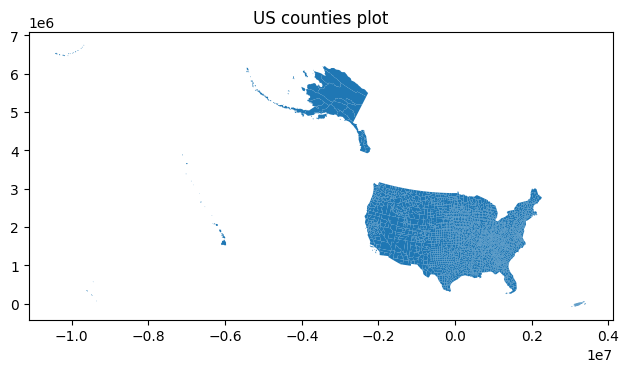

In [93]:
df_county.plot()
plt.title("US counties plot")
plt.tight_layout()
plt.savefig("../results/us_counties_plot.png", bbox_inches = "tight")

In [94]:
df_overlap = gpd.overlay(df, df_county, how = "intersection", keep_geom_type = True)
print(df_overlap.shape)
print(df_overlap.crs)
df_overlap.head()

(911, 13)
EPSG:5070


,object_id,feature_name,site_name,site_operational_status,state_name,area,area_log10,state_fip_code,county_fip_code,geo_id,county_name,county_area,geometry
0,1,NAVMEDCEN Portsmouth VA,NAVMEDCEN Portsmouth VA,Active,VA,4.707725e+05,5.672811,51,740,51740,Portsmouth City,1.209065e+08,"POLYGON ((1727043.898 1713108.337, 1727046.434..."
1,2,NAVSUPPACT Hampton Roads VA,NAVSUPPACT Hampton Roads VA,Active,VA,3.204949e+06,6.505821,51,710,51710,Norfolk City,2.496830e+08,"POLYGON ((1725463.024 1722134.743, 1725434.038..."
2,3,NNSY South Gate,NNSY South Gate,Active,VA,3.793155e+05,5.579001,51,740,51740,Portsmouth City,1.209065e+08,"POLYGON ((1728886.852 1708906.679, 1729332.258..."
3,4,Naval Support Activity Wash,Naval Support Activity Wash,Active,DC,3.098846e+05,5.491200,11,001,11001,District of Columbia,1.770260e+08,"POLYGON ((1622920.027 1923544.588, 1622927.039..."
4,5,Arlington Service Ctr,Arlington Service Ctr,Active,VA,7.847789e+04,4.894747,51,013,51013,Arlington County,6.760655e+07,"POLYGON ((1615739.643 1921565.228, 1615805.568..."


In [95]:
df_overlap["overlap_area"] = df_overlap.area
df_overlap.head()

,object_id,feature_name,site_name,site_operational_status,state_name,area,area_log10,state_fip_code,county_fip_code,geo_id,county_name,county_area,geometry,overlap_area
0,1,NAVMEDCEN Portsmouth VA,NAVMEDCEN Portsmouth VA,Active,VA,4.707725e+05,5.672811,51,740,51740,Portsmouth City,1.209065e+08,"POLYGON ((1727043.898 1713108.337, 1727046.434...",4.707725e+05
1,2,NAVSUPPACT Hampton Roads VA,NAVSUPPACT Hampton Roads VA,Active,VA,3.204949e+06,6.505821,51,710,51710,Norfolk City,2.496830e+08,"POLYGON ((1725463.024 1722134.743, 1725434.038...",3.204949e+06
2,3,NNSY South Gate,NNSY South Gate,Active,VA,3.793155e+05,5.579001,51,740,51740,Portsmouth City,1.209065e+08,"POLYGON ((1728886.852 1708906.679, 1729332.258...",3.793155e+05
3,4,Naval Support Activity Wash,Naval Support Activity Wash,Active,DC,3.098846e+05,5.491200,11,001,11001,District of Columbia,1.770260e+08,"POLYGON ((1622920.027 1923544.588, 1622927.039...",3.098846e+05
4,5,Arlington Service Ctr,Arlington Service Ctr,Active,VA,7.847789e+04,4.894747,51,013,51013,Arlington County,6.760655e+07,"POLYGON ((1615739.643 1921565.228, 1615805.568...",7.847789e+04


In [96]:
df_overlap["military_pct"] = (df_overlap["overlap_area"] / df_overlap["county_area"]).astype("Float64")
df_overlap.sort_values(by = "military_pct", ascending = False).head()

,object_id,feature_name,site_name,site_operational_status,state_name,area,area_log10,state_fip_code,county_fip_code,geo_id,county_name,county_area,geometry,overlap_area,military_pct
279,314,Fort Moore,Fort Moore,Active,GA,7.348411e+08,8.866193,13,053,13053,Chattahoochee County,6.505029e+08,"MULTIPOLYGON (((1034480.373 1085320.339, 10344...",4.908336e+08,0.754545
336,349,Fort Stewart,Fort Stewart,Active,GA,1.130710e+09,9.053351,13,029,13029,Bryan County,1.177036e+09,"POLYGON ((1369727.547 1103066.171, 1369699.201...",4.414959e+08,0.375091
281,316,Fort Liberty,Fort Liberty,Active,NC,6.268331e+08,8.797152,37,093,37093,Hoke County,1.014441e+09,"POLYGON ((1521428.694 1468445.405, 1521172.039...",3.625166e+08,0.357356
276,314,Fort Moore,Fort Moore,Active,GA,7.348411e+08,8.866193,13,215,13215,Muscogee County,5.724156e+08,"MULTIPOLYGON (((1030642.641 1093480.599, 10306...",1.917716e+08,0.335022
341,349,Fort Stewart,Fort Stewart,Active,GA,1.130710e+09,9.053351,13,179,13179,Liberty County,1.560517e+09,"POLYGON ((1368209.469 1089996.922, 1368113.888...",4.793383e+08,0.307166


In [97]:
df_overlap.crs

<Projected CRS: EPSG:5070>
Name: NAD83 / Conus Albers
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - CONUS onshore - Alabama; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming.
- bounds: (-124.79, 24.41, -66.91, 49.38)
Coordinate Operation:
- name: Conus Albers
- method: Albers Equal Area
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [98]:
df_overlap["county_name"].nunique()

451

In [101]:
dfj = df_overlap.groupby(["geo_id", "county_name"]).agg(
    military_count = ("object_id", "count"), 
    total_military_area_m = ("overlap_area", "sum"),
    pct_military = ("military_pct", "sum")
).reset_index()
dfj

,geo_id,county_name,military_count,total_military_area_m,pct_military
0,01003,Baldwin County,4,8.653933e+06,0.001648
1,01005,Barbour County,1,4.205022e+05,0.000179
2,01015,Calhoun County,3,1.549834e+08,0.097733
3,01031,Coffee County,6,6.410467e+07,0.036372
4,01035,Conecuh County,1,1.547288e+06,0.000701
...,...,...,...,...,...
523,72061,Guaynabo Municipio,1,1.842288e+06,0.025618
524,72075,Juana Díaz Municipio,1,3.026633e+06,0.0109
525,72123,Salinas Municipio,1,5.039522e+07,0.170501
526,72133,Santa Isabel Municipio,1,3.451007e+04,0.000173


In [103]:
dfj.nlargest(10, "pct_military")

,geo_id,county_name,military_count,total_military_area_m,pct_military
100,13053,Chattahoochee County,1,4.908336e+08,0.754545
34,04027,Yuma County,4,5.739899e+09,0.401561
96,13029,Bryan County,1,4.414959e+08,0.375091
321,37093,Hoke County,2,3.625306e+08,0.35737
292,35035,Otero County,3,6.060971e+09,0.353133
119,13215,Muscogee County,1,1.917716e+08,0.335022
112,13179,Liberty County,1,4.793383e+08,0.307166
89,12091,Okaloosa County,6,9.884620e+08,0.306129
454,49045,Tooele County,4,5.743402e+09,0.304356
245,28111,Perry County,1,4.814838e+08,0.285914


In [104]:
dfj.to_csv("../processed_data/military_by_county.csv")